In [ ]:
#libraries for prediction

#!pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels jupyter==1.0.0 notebook==7.2.0 ipykernel==6.29.4


In [1]:
# import packages

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt # for visual representation
from sklearn.model_selection import train_test_split # to split the data in testing and training set
from sklearn.linear_model import LinearRegression # Model
from sklearn.preprocessing import StandardScaler # Data pre-processing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # check for deviations

print('imported....')

imported....


In [3]:
# load CSV file
df = pd.read_csv('house_price_data.csv')
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
0,3774,2,3,28,16.1,1,3,446385
1,4107,4,2,17,23.3,1,3,489543
2,1460,2,3,17,7.3,0,1,185140
3,1894,2,3,1,NaN,1,1,286522
4,1730,4,2,34,3.5,0,2,212784


In [4]:
# describe the data
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,Price_USD
count,100.000000,100.000000,100.000000,100.000000,97.000000,100.000000,100.000000,100.000000
mean,2717.380000,2.980000,2.040000,21.440000,14.676289,0.420000,1.890000,328377.300000
std,1104.021197,1.476961,0.839913,11.001671,8.517332,0.496045,0.827495,134402.974694
min,621.000000,1.000000,1.000000,0.000000,1.400000,0.000000,1.000000,55418.000000
25%,1807.250000,1.750000,1.000000,14.000000,6.700000,0.000000,1.000000,210127.250000
50%,2791.500000,3.000000,2.000000,22.500000,14.800000,0.000000,2.000000,332383.500000
75%,3622.000000,4.000000,3.000000,31.000000,21.400000,1.000000,3.000000,439099.250000
max,4493.000000,5.000000,3.000000,39.000000,29.700000,1.000000,3.000000,578851.000000


In [11]:
# check for blank values
print('check no of null values',df.isnull().sum())
print('\ncheck no of NOT null values',df.notnull().sum())

print('overall view')
print(df.info())

check no of null values Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_years              0
Distance_to_city_km    3
Garage                 0
Floors                 0
Price_USD              0
dtype: int64

check no of NOT null values Area_sqft              100
Bedrooms               100
Bathrooms              100
Age_years              100
Distance_to_city_km     97
Garage                 100
Floors                 100
Price_USD              100
dtype: int64
overall view
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area_sqft            100 non-null    int64  
 1   Bedrooms             100 non-null    int64  
 2   Bathrooms            100 non-null    int64  
 3   Age_years            100 non-null    int64  
 4   Distance_to_city_km  97 non-null     float64
 5   Garage               100 non-null    int64  


In [14]:
# fill the null values
df.fillna(df.mean(), inplace=True)

#verify the null values
print('--------verify the null values-----')
print(df.isnull().sum())

--------verify the null values-----
Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_years              0
Distance_to_city_km    0
Garage                 0
Floors                 0
Price_USD              0
dtype: int64


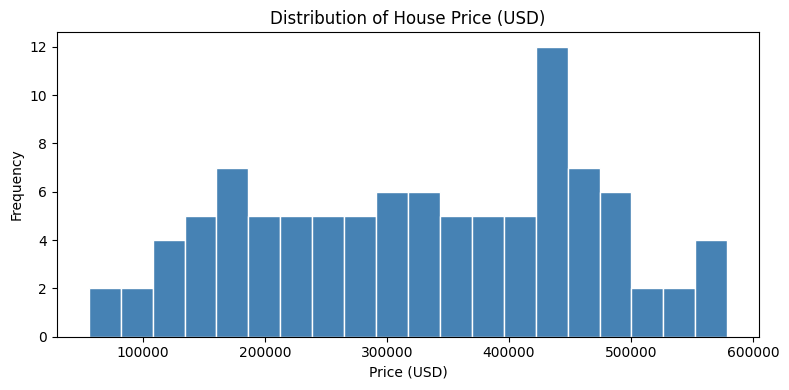

In [28]:
# Chart — Distribution of House Price (Target Variable)
plt.figure(figsize=(8, 4))
plt.hist(df['Price_USD'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of House Price (USD)')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [19]:
# extract the features and to be predict columns
features = ['Area_sqft','Bedrooms','Bathrooms','Age_years','Distance_to_city_km','Garage','Floors']
predict = ['Price_USD']
x = df[features]
y = df[predict]

print('-----features-----')
print(x)
print('-----output-----')
print(y)

-----features-----
    Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_to_city_km  Garage  \
0        3774         2          3         28            16.100000       1   
1        4107         4          2         17            23.300000       1   
2        1460         2          3         17             7.300000       0   
3        1894         2          3          1            14.676289       1   
4        1730         4          2         34             3.500000       0   
..        ...       ...        ...        ...                  ...     ...   
95       4443         3          3         21            29.700000       0   
96       4493         3          2         21            13.000000       0   
97       2100         1          1          5            11.800000       1   
98       1302         5          3         14            23.500000       1   
99       3049         1          1         36            10.900000       0   

    Floors  
0        3  
1        3  
2    

In [38]:
# split the data set into training and testing sets
# keep 80:20 ratio for training : testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=35)
print(f'x_train shape {x_train.shape}, x_test shape {x_test.shape}, y_train shape {y_train.shape}, y_test shape {y_test.shape}')
print(x_test)

x_train shape (80, 7), x_test shape (20, 7), y_train shape (80, 1), y_test shape (20, 1)
    Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_to_city_km  Garage  \
40       1682         1          1         28                  2.2       0   
71       2641         3          2         38                 28.9       0   
98       1302         5          3         14                 23.5       1   
27       3033         1          3         33                 20.1       0   
70        841         3          2          8                 12.2       1   
31       1784         3          2         27                 17.1       1   
10       1066         5          2         13                 29.3       0   
24       2115         4          1          7                  8.3       1   
51       3605         5          3         22                 19.4       1   
35       2900         1          3          3                 11.3       1   
13       2082         4          3          7        

In [36]:
# train the data

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
# run the prediction
y_pred = model.predict(x_test)
y_pred

array([[173057.43385473],
       [224960.47572117],
       [207182.2013478 ],
       [302103.15884648],
       [154966.55777423],
       [214897.70671279],
       [132957.66849899],
       [316786.39198723],
       [466912.4168824 ],
       [396052.35359174],
       [280934.32436181],
       [301230.57711718],
       [436448.0774481 ],
       [135977.38858195],
       [518035.82086133],
       [448508.63506867],
       [394819.56551394],
       [335904.20844453],
       [182068.45907083],
       [487327.93306231]])

In [40]:
y_test

,Price_USD
40,154868
71,224645
98,199575
27,304828
70,161642
31,244621
10,165797
24,312867
51,468519
35,413356


In [46]:
mae = mean_absolute_error(y_test,y_pred)
print(mae)

rmse = np.sqrt( mean_squared_error(y_test, y_pred) )
print(rmse)

r2 = r2_score(y_test, y_pred)
print(r2)

12614.19606055043
17048.5526652042
0.9797496701374047


In [47]:
new_houses = pd.DataFrame({
    'Area_sqft'           : [1500, 3000],
    'Bedrooms'            : [2,    4   ],
    'Bathrooms'           : [1,    3   ],
    'Age_years'           : [10,   5   ],
    'Distance_to_city_km' : [15,   8   ],
    'Garage'              : [0,    1   ],
    'Floors'              : [1,    2   ]
})
new_houses

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors
0,1500,2,1,10,15,0,1
1,3000,4,3,5,8,1,2


In [49]:
prediction = model.predict(new_houses)
prediction

new_houses['predicted_price_USD'] = prediction
new_houses

,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_city_km,Garage,Floors,predicted_price_USD
0,1500,2,1,10,15,0,1,166749.015744
1,3000,4,3,5,8,1,2,457587.771997


In [50]:
print(model.intercept_)

[12475.69526494]


In [53]:
coef = pd.DataFrame({'Features' : features, 'Coeffecient':model.coef_[0]})
coef



# hyper parameter tuning,
# gross validation
# how to improve model effiency 

,Features,Coeffecient
0,Area_sqft,118.882147
1,Bedrooms,14542.306396
2,Bathrooms,10681.788626
3,Age_years,-2356.593740
4,Distance_to_city_km,-3252.567271
5,Garage,18978.261092
6,Floors,8538.144972
